In [1]:
import os
os.chdir('/Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning')
print("Current working directory: {0}".format(os.getcwd()))

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload
%autoreload 2

Current working directory: /Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset

from typing import List
from tqdm import tqdm
import math


from src.batchbald_redux import (
    active_learning,
    batchbald,
    consistent_mc_dropout,
    joint_entropy,
)

import argparse
import sys
from tqdm import tqdm
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import torch
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms

from src.models.model import MLP, PaperCNN
from src.data.data import TwoMoons, MNIST_CUSTOM
from src.models.train_model import train, test

device = 'cpu'

In [3]:
def get_logits(model,
               dataset,
               T):
    
    dataloader = DataLoader(dataset, batch_size=1000, shuffle=False)
    
    idxs = []
    outputs = []

    model.train()
    with torch.no_grad():
        for t in range(T):
            outputs_inner = []
            for i, batch in tqdm(enumerate(dataloader), leave=False):
                X, y, idx = batch
                outputs_inner.append(F.softmax(model(X.to(device)), dim = 1))
                idxs.extend(idx.tolist())
            outputs.append(torch.cat(outputs_inner, dim=0))

    logits = torch.stack(outputs, dim = 1)
    
    return logits

def train_val(model,
              trainloader,
              testloader,
              optimizer,
              num_epochs: int,
              num_test_inference_samples = 10
              ):
    test_loss = []
    test_accs = []
    
    for epoch in tqdm(range(num_epochs)):
        model.train()

        # Train
        for data, target in tqdm(trainloader, desc="Training", leave=False):
            data = data.to(device=device)
            target = target.to(device=device)
            
            optimizer.zero_grad()

            prediction = model(data, 1).squeeze(1)

            loss = F.nll_loss(prediction, target)

            loss.backward()
            optimizer.step()

        # Test
        loss = 0
        correct = 0
        with torch.no_grad():
            for data, target in tqdm(testloader, desc="Testing", leave=False):
                data = data.to(device=device)
                target = target.to(device=device)

                prediction = torch.logsumexp(model(data, num_test_inference_samples), dim=1) - math.log(
                    num_test_inference_samples
                )
                loss += F.nll_loss(prediction, target, reduction="sum")

                prediction = prediction.max(1)[1]
                correct += prediction.eq(target.view_as(prediction)).sum().item()

        loss /= len(testloader.dataset)
        test_loss.append(loss)**

        percentage_correct = 100.0 * correct / len(testloader.dataset)
        test_accs.append(percentage_correct)

        print("Test set: Average loss: {:.4f}, Accuracy: ({:.2f}%)".format(loss, percentage_correct))
        
    return model, optimizer, test_accs, test_loss


def get_logits_box(model,
                   testdata,
                   testloader,
                   num_inference_samples = 10
                   ):
    """ Acquire pool predictions """
    
    N = len(testdata)
    logits_N_K_C = torch.empty(
        (N, num_inference_samples, 10),
        dtype=torch.float64
    )

    with torch.no_grad():
        model.eval()

        for i, (data, _) in enumerate(tqdm(testloader, desc="Evaluating Acquisition Set", leave=False)):
            data = data.to(device=device)

            lower = i * testloader.batch_size
            upper = min(lower + testloader.batch_size, N)
            logits_N_K_C[lower:upper].copy_(model(data, num_inference_samples), non_blocking=True)
    
    return logits_N_K_C
        
    

SyntaxError: invalid syntax (2329447965.py, line 68)

In [4]:
from src.models.model import PaperCNN, BayesianCNN
from src.data.data import ActiveLearningDataset
from torchvision.datasets import MNIST
from typing import List
from src.features.acquistion_functions import query_the_oracle

TEST_ACC = []

# AL parameters
num_queries = 10
query_size = 4
T = 10

# get an active learning dataset
mnist_train = MNIST_CUSTOM(root='./data/raw', train=True, transform=transforms.ToTensor())
mnist_test = MNIST_CUSTOM(root='./data/raw', train=False, transform=transforms.ToTensor())
testloader = DataLoader(mnist_test, batch_size=512, shuffle=False, num_workers=0)

al_dataset = ActiveLearningDataset(mnist_train)

# call to get balanced initial pool
al_dataset.get_initial_balanced_trainset(n_per_class=2)

# define model
model = PaperCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-4)

#model = BayesianCNN(10).to(device=device)  # initialise model
#optimizer = optim.Adam(model.parameters(), lr=1e-4)


# start querying from the unlabeled pool
loop = tqdm(range(num_queries))
for query in loop:
    # train on labeled pool subset
    trainloader = DataLoader(al_dataset.training_dataset, batch_size=256, num_workers=0,shuffle = False)
    
    # train on initial pool 
    print(f'Training...')
    model, optimizer = train(model, trainloader, optimizer, device, num_epochs=50, val = False, plot = False, printout = False)
    test_acc = test(model, testloader, device, display=False)
    TEST_ACC.append(test_acc)
    
    print(f'Creating logits box...')
    logits_N_K_C = get_logits(model,
                              al_dataset.pool_dataset,
                              T = T)
    
    print(f'Querying a batch...')
    candidate_batch = batchbald.get_batchbald_batch(
                            logits_N_K_C,
                            query_size,
                            100000,
                            dtype=torch.float64,
                            device=device
                )
    
    # update labeled pool with queried data points
    al_dataset.acquire_samples(candidate_batch.indices)
    
    dataset_indices = al_dataset.get_dataset_indices(
            candidate_batch.indices
        )
    
    print("Dataset indices: ", dataset_indices)
    print("Scores: ", candidate_batch.scores)  
    
    # loop info
    loop.set_description(f"Query [{query}/{num_queries}]")
    loop.set_postfix(test_acc=test_acc)
    

plt.figure(figsize=(10,6))
with sns.axes_style("whitegrid"):
    plt.plot(TEST_ACC)

  0%|          | 0/10 [00:00<?, ?it/s]

Training...
Creating logits box...


Querying a batch...


Conditional Entropy:   0%|          | 0/59980 [00:00<?, ?it/s]

BatchBALD:   0%|          | 0/4 [00:00<?, ?it/s]

...

ExactJointEntropy.compute_batch:   0%|          | 0/59952 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/59952 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/59952 [00:00<?, ?it/s]

Query [7/10]:  80%|████████  | 8/10 [14:09<03:33, 106.81s/it, test_acc=65.2]

Dataset indices:  [54078 35976 43121 59960]
Scores:  [0.3944028777995203, -30.661813480560532, -526.4288702151721, -7589.734664724362]
Training...
Creating logits box...


In [4]:
class BayesianCNN(consistent_mc_dropout.BayesianModule):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv1_drop = consistent_mc_dropout.ConsistentMCDropout2d()
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.conv2_drop = consistent_mc_dropout.ConsistentMCDropout2d()
        self.fc1 = nn.Linear(1024, 128)
        self.fc1_drop = consistent_mc_dropout.ConsistentMCDropout()
        self.fc2 = nn.Linear(128, num_classes)

    def mc_forward_impl(self, input: torch.Tensor):
        input = F.relu(F.max_pool2d(self.conv1_drop(self.conv1(input)), 2))
        input = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(input)), 2))
        input = input.view(-1, 1024)
        input = F.relu(self.fc1_drop(self.fc1(input)))
        input = self.fc2(input)
        input = F.log_softmax(input, dim=1)

        return input

In [6]:
from src.models.model import PaperCNN
from src.data.data import ActiveLearningDataset
from torchvision.datasets import MNIST
from typing import List
from src.features.acquistion_functions import query_the_oracle

TEST_ACC = []
TEST_LOSS = []

# AL parameters
num_queries = 10
query_size = 4
T = 10

num_classes = 10
num_inference_samples = 10
num_test_inference_samples = 5
num_samples = 100000  # Total number of samples

test_batch_size = 512  # Test Loader Batch size
batch_size = 64 # Train loader Batch size
scoring_batch_size = 128  # Pool Loader Batch size
training_iterations = 4096 * 6


# get an active learning dataset
mnist_train = MNIST(root='./data/raw', train=True, transform=transforms.ToTensor())
mnist_test = MNIST(root='./data/raw', train=False, transform=transforms.ToTensor())
al_dataset = ActiveLearningDataset(mnist_train)

# call to get balanced initial pool
al_dataset.get_initial_balanced_trainset(n_per_class=2)

al_dataset.extract_dataset_from_pool(
            40000
        )  # Extracts 40000 samples from pool and makes it as validation dataset

# define model
#model = PaperCNN().to(device)
#optimizer = optim.Adam(model.parameters(), lr = 1e-4)

model = BayesianCNN(num_inference_samples).to(device=device)  # initialise model
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# train on labeled pool subset
train_loader = DataLoader(
        al_dataset.training_dataset,
        sampler=active_learning.RandomFixedLengthSampler(
            al_dataset.training_dataset, training_iterations
        ),
        batch_size=batch_size
    )

pool_loader = DataLoader(
            al_dataset.pool_dataset,
            batch_size=scoring_batch_size,
            shuffle=False
        )

test_loader = DataLoader(
            mnist_test,
            batch_size=test_batch_size,
            shuffle=False
        )
        

# start querying from the unlabeled pool
loop = tqdm(range(num_queries))
for query in loop:


    # Train
    print(f'Training...')
    print(len(train_loader.dataset))
    for data, target in tqdm(train_loader, desc="Training", leave=False):
        data = data.to(device=device)
        target = target.to(device=device)

        optimizer.zero_grad()

        prediction = model(data, 1).squeeze(1)
        loss = F.nll_loss(prediction, target)

        loss.backward()
        optimizer.step()

    print(f'Testing...')
    # Test
    loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in tqdm(test_loader, desc="Testing", leave=False):
            data = data.to(device=device)
            target = target.to(device=device)

            prediction = torch.logsumexp(model(data, num_test_inference_samples), dim=1) - math.log(
                num_test_inference_samples
            )
            loss += F.nll_loss(prediction, target, reduction="sum")

            prediction = prediction.max(1)[1]
            correct += prediction.eq(target.view_as(prediction)).sum().item()

    loss /= len(test_loader.dataset)
    TEST_LOSS.append(loss)

    test_acc = 100.0 * correct / len(test_loader.dataset)
    TEST_ACC.append(test_acc)
    

    print("Test set: Average loss: {:.4f}, Accuracy: ({:.2f}%)".format(loss, test_acc))

    # Acquire pool predictions
    N = len(al_dataset.pool_dataset)
    logits_N_K_C = torch.empty(
        (N, num_inference_samples, 10),
        dtype=torch.double
    )
    
    print(f'Querying samples...')
    with torch.no_grad():
        model.eval()

        for i, (data, _) in enumerate(tqdm(pool_loader, desc="Evaluating Acquisition Set", leave=False)):
            data = data.to(device=device)

            lower = i * pool_loader.batch_size
            upper = min(lower + pool_loader.batch_size, N)
            logits_N_K_C[lower:upper].copy_(model(data, num_inference_samples).double(), non_blocking=True)

    with torch.no_grad():
        candidate_batch = batchbald.get_batchbald_batch(
            logits_N_K_C,
            query_size,
            num_samples,
            dtype=torch.float64,
            device=device  
        )
    
    # update labeled pool with queried data points
    al_dataset.acquire_samples(candidate_batch.indices)
    
    dataset_indices = al_dataset.get_dataset_indices(
            candidate_batch.indices
        )
    
    print("Dataset indices: ", dataset_indices)
    print("Scores: ", candidate_batch.scores)  
    
    # loop info
    loop.set_description(f"Query [{query}/{num_queries}]")
    loop.set_postfix(test_acc=test_acc)
    

plt.figure(figsize=(10,6))
with sns.axes_style("whitegrid"):
    plt.plot(TEST_ACC)

  0%|          | 0/10 [00:00<?, ?it/s]

Training...
20


Testing...


Test set: Average loss: 1.3025, Accuracy: (60.03%)
Querying samples...


Conditional Entropy:   0%|          | 0/19980 [00:00<?, ?it/s]

...

ExactJointEntropy.compute_batch:   0%|          | 0/19980 [00:00<?, ?it/s]

Query [0/10]:  10%|█         | 1/10 [00:39<05:56, 39.57s/it, test_acc=60]

Dataset indices:  [59439 24523  2744  8509]
Scores:  [0.8750131810514731, 1.4350689725766803, 1.7529441021018917, 1.9606925377783626]
Training...
24


Query [0/10]:  10%|█         | 1/10 [00:39<05:56, 39.66s/it, test_acc=60]


ValueError: Expected input batch_size (64000) to match target batch_size (64).

Epoch:   0 | Train Loss: 0.95 | Train Acc: 73.0%
Epoch:   1 | Train Loss: 0.40 | Train Acc: 87.8%
Epoch:   2 | Train Loss: 0.32 | Train Acc: 90.6%


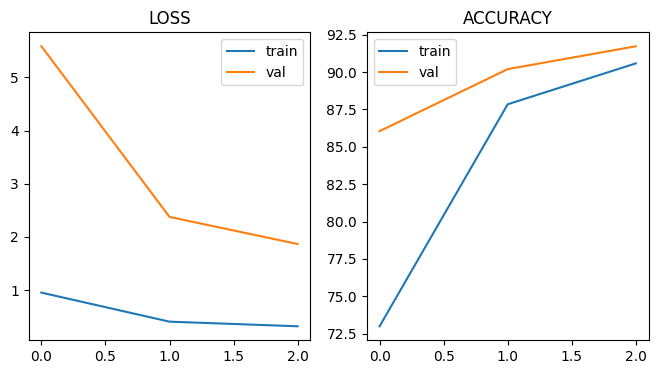

In [3]:
# train and test data
traindata = MNIST_CUSTOM(root='data/raw', train = True, transform = transforms.ToTensor())
testdata = MNIST_CUSTOM(root='data/raw', train = False, transform = transforms.ToTensor())

trainloader = DataLoader(traindata, batch_size=256)
testloader = DataLoader(testdata, batch_size=256)

model = PaperCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-4)
model, optim = train(model, trainloader, optimizer, device, testloader, num_epochs=3, val=True)

In [4]:
def get_logits(model,
               dataloader)
    idxs = []
    outputs = []

    model.train()
    with torch.no_grad():
        for t in range(10):
            outputs_inner = []
            for i, batch in tqdm(enumerate(dataloader), leave=False):
                X, y, idx = batch
                outputs_inner.append(F.softmax(model(X.to(device)), dim = 1))
                idxs.extend(idx.tolist())
            outputs.append(torch.cat(outputs_inner, dim=0))

    logits = torch.stack(outputs, dim = 1)
    
    return logits
    
    

In [5]:
candidate_batch = batchbald.get_batchbald_batch(
                    outputs,
                    4,
                    100000,
                    dtype=torch.float64,
                    device=device,  # Returns the indices and scores(Mutual Information) for the batch selected by Batchbald/BALD Strategy.
                )

Conditional Entropy:   0%|          | 0/60000 [00:00<?, ?it/s]

BatchBALD:   0%|          | 0/4 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/60000 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/60000 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/60000 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/60000 [00:00<?, ?it/s]

In [6]:
candidate_batch

CandidateBatch(scores=[0.28304554781141467, -28.8528190776765, -498.8554375069883, -7222.701267626055], indices=[51794, 40720, 42526, 35734])

In [4]:
def train_val(model,
              trainloader,
              testloader,
              optimizer,
              num_epochs: int,
              num_test_inference_samples = 10
              ):
    test_loss = []
    test_accs = []
    
    for epoch in tqdm(range(num_epochs)):
        model.train()

        # Train
        for data, target in tqdm(trainloader, desc="Training", leave=False):
            data = data.to(device=device)
            target = target.to(device=device)
            
            optimizer.zero_grad()

            prediction = model(data, 1).squeeze(1)

            loss = F.nll_loss(prediction, target)

            loss.backward()
            optimizer.step()

        # Test
        loss = 0
        correct = 0
        with torch.no_grad():
            for data, target in tqdm(testloader, desc="Testing", leave=False):
                data = data.to(device=device)
                target = target.to(device=device)

                prediction = torch.logsumexp(model(data, num_test_inference_samples), dim=1) - math.log(
                    num_test_inference_samples
                )
                loss += F.nll_loss(prediction, target, reduction="sum")

                prediction = prediction.max(1)[1]
                correct += prediction.eq(target.view_as(prediction)).sum().item()

        loss /= len(testloader.dataset)
        test_loss.append(loss)**

        percentage_correct = 100.0 * correct / len(testloader.dataset)
        test_accs.append(percentage_correct)

        print("Test set: Average loss: {:.4f}, Accuracy: ({:.2f}%)".format(loss, percentage_correct))
        
    return model, optimizer, test_accs, test_loss


def get_logits_box(model,
                   testdata,
                   testloader,
                   num_inference_samples = 10
                   ):
    """ Acquire pool predictions """
    
    N = len(testdata)
    logits_N_K_C = torch.empty(
        (N, num_inference_samples, 10),
        dtype=torch.float64
    )

    with torch.no_grad():
        model.eval()

        for i, (data, _) in enumerate(tqdm(testloader, desc="Evaluating Acquisition Set", leave=False)):
            data = data.to(device=device)

            lower = i * testloader.batch_size
            upper = min(lower + testloader.batch_size, N)
            logits_N_K_C[lower:upper].copy_(model(data, num_inference_samples), non_blocking=True)
    
    return logits_N_K_C
        

SyntaxError: invalid syntax (3770359609.py, line 45)

In [4]:
from src.models.model import BayesianCNN

num_queries = 3
query_size = 4
num_epochs = 5
num_inference_samples = 10
num_test_inference_samples = 5
batch_size = 256
scoring_batch_size = 4

# train and test data
traindata = MNIST(root='data/raw', train = True, transform = transforms.ToTensor())
testdata = MNIST(root='data/raw', train = False, transform = transforms.ToTensor())

testloader = DataLoader(testdata, batch_size=256)

model = BayesianCNN(10).to(device=device)  # initialise model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

initial_idx = []
for r in range(10):
    initial_idx.extend(np.random.choice(np.where(traindata.targets ==r)[0], size=2, replace=False))

active_learning_data = active_learning.ActiveLearningData(traindata)
active_learning_data.acquire(
            initial_idx
        )  

test_accs = []
test_loss = []
added_indices = []

# start querying from the unlabeled pool
loop = tqdm(range(num_queries))
for query in loop:
    
    print(f'Length of trainset: {len(active_learning_data.training_dataset)}')
    print(f'Length of poolset: {len(active_learning_data.pool_dataset)}')
    
    train_loader = DataLoader(
            active_learning_data.training_dataset,
            batch_size=batch_size,
        )

    pool_loader = DataLoader(
                active_learning_data.pool_dataset,
                batch_size=scoring_batch_size,
                shuffle=False            
        )
    
    test_loader = DataLoader(
                testdata,
                batch_size=512,
                shuffle=False
            )
    
    model, optimizer, test_acc, test_loss = train_val(model, train_loader, test_loader, optimizer, num_epochs=15)
    test_accs.append(test_acc)
    test_loss.append(test_loss)
    
    logits_N_K_C = get_logits_box(model, testdata, test_loader, num_inference_samples = 10)
    
    # update labeled pool with queried data points
    candidate_batch = batchbald.get_batchbald_batch(
                    logits_N_K_C,
                    query_size,
                    100000,
                    dtype=torch.float64,
                    device=device
    )
    
    dataset_indices = active_learning_data.get_dataset_indices(
            candidate_batch.indices
        )
    print("Dataset indices: ", dataset_indices)
    print("Scores: ", candidate_batch.scores)  
    
    # update training set and pool set
    active_learning_data.acquire(candidate_batch.indices)
    added_indices.append(dataset_indices)
      
    # loop info
    loop.set_description(f"Query [{query}/{num_queries}]")
    loop.set_postfix(test_acc=test_acc)
    

  0%|          | 0/3 [00:00<?, ?it/s]

Length of trainset: 20
Length of poolset: 59980


Test set: Average loss: 2.3022, Accuracy: (11.40%)


Test set: Average loss: 2.3015, Accuracy: (10.95%)


Test set: Average loss: 2.3006, Accuracy: (10.83%)


...

Query [0/3]:  33%|███▎      | 1/3 [02:13<04:27, 133.52s/it, test_acc=[11.4, 10.95, 10.83, 11.0, 11.53, 11.68, 11.84, 11.99, 12.53, 13.03, 13.48, 14.74, 15.28, 16.41, 17.6]]

Dataset indices:  [7840  894 5964 6156]
Scores:  [0.014725748300734587, 0.02908757898281511, 0.043131432321017016, 0.057079863387805574]
Length of trainset: 24
Length of poolset: 59976


Test set: Average loss: 2.2578, Accuracy: (17.67%)


Test set: Average loss: 2.2524, Accuracy: (17.43%)


Test set: Average loss: 2.2474, Accuracy: (16.70%)


In [20]:
candidate_batch = batchbald.get_batchbald_batch(
                    logits_N_K_C,
                    4,
                    100000,
                    dtype=torch.float64,
                    device=device,  # Returns the indices and scores(Mutual Information) for the batch selected by Batchbald/BALD Strategy.
                )

Conditional Entropy:   0%|          | 0/10000 [00:00<?, ?it/s]

BatchBALD:   0%|          | 0/4 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/10000 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/10000 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/10000 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/10000 [00:00<?, ?it/s]

In [21]:
candidate_batch

CandidateBatch(scores=[0.8064845257275581, 1.3158776139449855, 1.669505667125859, 1.8872203903480793], indices=[1609, 2107, 4111, 1299])

In [13]:
candidate_batch

CandidateBatch(scores=[nan, nan, nan, nan], indices=[0, 10, 1, 2])

In [ ]:
from src.models.model import PaperCNN
from src.data.data import ActiveLearningDataset
from torchvision.datasets import MNIST
from typing import List
from src.features.acquistion_functions import query_the_oracle

TEST_ACC = []

# AL parameters
num_queries = 20
query_size = 50
T = 30

# get an active learning dataset
mnist_train = MNIST_CUSTOM(root='./data/raw', train=True, transform=transforms.ToTensor())
mnist_test = MNIST_CUSTOM(root='./data/raw', train=False, transform=transforms.ToTensor())
testloader = DataLoader(mnist_test, batch_size=512, shuffle=False, num_workers=0)

al_dataset = ActiveLearningDataset(mnist_train)

# call to get balanced initial pool
al_dataset.get_initial_balanced_trainset(n_per_class=2)

# define model
model = PaperCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-4)
trainloader = DataLoader(al_dataset.training_dataset, batch_size=256, shuffle=False, num_workers=0)

# train on initial pool 
model, optimizer = train(model, trainloader, optimizer, device, num_epochs=50, val = False, plot = True, printout = False)

TEST_ACC.append(test(model, testloader, device, display=False))

# start querying from the unlabeled pool
loop = tqdm(range(num_queries))
for query in loop:
    
    # query data points from unlabeled pool
    query_batch = query_the_oracle(device,
                                      model,
                                      al_dataset.pool_dataset,
                                      T = T,
                                      query_size=query_size,
                                      query_strategy= 'random',
                                      bald_method='MC_drop'
                                  )
    
    # update labeled pool with queried data points
    al_dataset.acquire_samples(query_batch.indices)
    
    # train on labeled pool subset
    labeled_loader = DataLoader(al_dataset.training_dataset, batch_size=256, num_workers=0,shuffle = False)
    model, optimizer = train(model, labeled_loader, optimizer, device, num_epochs=50, val = False, plot = False, printout = False)
    acc = test(model, testloader, device, display = False)
    
    # test model
    test_acc = test(model, testloader, device, display=False)
    TEST_ACC.append(test_acc)
    
    # loop info
    loop.set_description(f"Query [{query}/{num_queries}]")
    loop.set_postfix(test_acc=test_acc)
    
    